In [2]:
''' Import required packages
'''

import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from pykalman import KalmanFilter
from numba import njit


In [ ]:
''' A function enabling us to sample from the true, underlying 
linear-Gaussian state space model
'''

def sample_state_space_model(us, T=200):
    """Sample observations from the toy example 
    linear-Gaussian state-space model (under the true
    theta parameter) described in Svensson et al. (2017).

    Parameters
    -
    T : int, default=500
        Number of time steps to simulate.
    us : ndarray of shape (T,):
        List of exogenous input variables.

    Returns
    -
    ys : ndarray of shape (T,)
        Simulated observations generated from the state space model.
    """

    xs = np.zeros((2,T)) # Storage for latent states
    ys = np.zeros((T,)) # Storage for observations
    transition_matrix = np.array([[1, 0.8],[0, 0.1]])
    observation_matrix = np.array([1, 0])
    xs[:,0] = [0, 0] # Initial condition
    for i in range(1, T):
        # Evolve latent space according to formula
        # in Svensson et al. (2017).
        xs[:,i] = transition_matrix @ xs[:,i-1] \
                  + np.array([-1, 0]) * us[i] \
                  + np.random.multivariate_normal(np.zeros(2), np.eye(2))
        ys[i] = observation_matrix @ xs[:,i]
    return ys

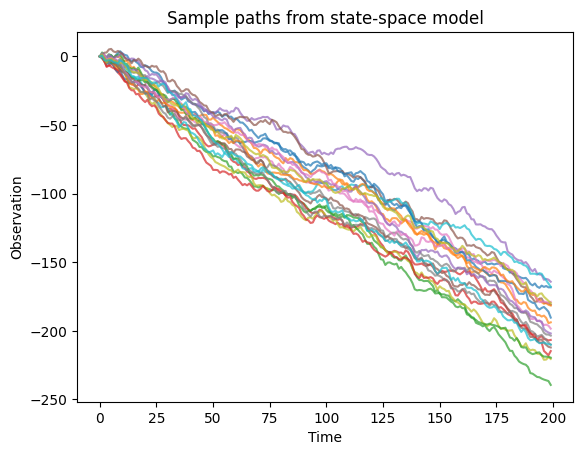

In [231]:
''' Draw sample paths from the state-space model defined above.
Do some quick visualization.
'''


n_paths = 20 # Number of paths to draw
T = 500 # Number of samples in each path

rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=1, scale=1, size=T) # Fixed exogenous input variables

for _ in range(n_paths):
    ys = sample_state_space_model(us=us)
    plt.plot(ys, alpha=0.7)

plt.title("Sample paths from state-space model")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.show()

In [237]:
'''Implementation of a Metropolis-Hastings algorithm for sampling parameters
from a tempered version of the linear-Gaussian state space model defined above.
'''

def metropolis_hastings(initial_theta, temp, ys, us, n_iters=1, proposal_sd=0.01, verbose=False):
    """Draw samples from the posterior ``p(theta|y_1:T,lambda)`` 
    of the tempered linear-Gaussian state space model described 
    in Svensson et al. (2017)  using a random-walk 
    Metropolis-Hastings algorithm with a bivariate normal proposal.
    
    Parameters
    -
    initial_theta : float
                    Initial point from whence to construct the
                    Metropolis-Hastings Markov chain.
    temp          : float
                    Tempering parameter of the distribution to sample
                    from.
    ys            : ndarray of shape (T,)
                    List of observations on which the distribution to
                    sample from is conditioned.
    n_iters       : int, default=1
                    Number of iterations to run the Metropolis-Hastings
                    algorithm for.
    proposal_sd   : float, default=0.01
                    Standard deviation of the proposal distribution.
    verbose       : Boolean, default=False
                    Whether or not to print additional diagnostic information
                    while running the algorithm
    """
    
    if(verbose):
        print(f'Starting Metropolis-Hastings run\n \
                Parameters: \n \
                initial position = {initial_theta}\n \
                tempering        = {temp}\n \
                iterations       = {n_iters}\n \
                proposal_sd      = {proposal_sd}')
    samples = np.zeros((n_iters,2))
    samples[0,:] = initial_theta
    # Cache the log-likelihood so it doesn't have to be computed
    # twice each loop
    current_log_posterior = log_likelihood(ys=ys, us=us, theta=initial_theta, temp=temp) + log_prior(initial_theta)
    n_accepts = 0
    for i in range(1, n_iters):
        y = samples[i-1,:]
        # Random walk Metropolis-Hastings with multivariate normal proposal
        z = np.random.multivariate_normal(y, proposal_sd**2 * np.eye(2))
        d = np.random.uniform(0, 1)
        new_log_posterior = log_likelihood(ys=ys, us=us, theta=z, temp=temp) + log_prior(z)
        # Compute acceptance probability in log scale to avoid underflow
        log_alpha = new_log_posterior - current_log_posterior
        if np.log(d) < min(log_alpha, 0):
            samples[i] = z
            current_log_posterior = new_log_posterior
            n_accepts += 1
        else:
            samples[i] = y
    if(verbose):
        print(f'Finished Metropolis-Hastings run \n \
                Acceptance rate: {n_accepts / n_iters}')
    return samples


def log_prior(theta):
    """Returns the log of the prior distribution on the parameter.
    The prior is uniform on [0,2.5] x [-2.5,0].

    Parameters
    -
    theta : float
            Point at which to evaluate the log of the prior.
    """
    if -2.5 <= theta[0] <= 2.5 and -2.5 <= theta[1] <= 2.5:
        return 0.0
    else:
        return -np.inf
    

def sample_prior(size=1):
    """Samples points from the prior distribution on theta.
    The prior is the uniform distribution on [0,2.5] x [-2.5,0].
    
    Parameters
    -
    size : int
           Number of points to sample.
    """
    if size == 1:
        return np.asarray([np.random.uniform(-2.5, 2.5), np.random.uniform(-2.5,2.5)])
    else:
        return np.asarray([[np.random.uniform(-2.5, 2.5), np.random.uniform(-2.5,2.5)] for _ in range(size)])


@njit # This makes it faster
def log_likelihood(ys, theta, us, temp):
    """ Computes the log-likelihood of the tempered linear-Gaussian 
    state space model using the Kalman filter.
    
    Parameters
    -
    ys    : ndarray of shape (T,)
          List of observations on which to evaluate the log-likelihood.
    theta : float
          Parameter value at which to evaluate the log-likelihood.
    temp  : float
          Tempering strength of the state-space model for which to
          calculate the log-likelihood.
    us    : ndarray of shape (T,)
          Exogenous input variables.
    """
    
    theta1 = theta[0]
    theta2 = theta[1]

    # Initial state: x_0 = [0, 0]
    m0, m1 = 0.0, 0.0

    P00, P01 = 0.0, 0.0 # 0.0, 0.0 initial condition
    P10, P11 = 0.0, 0.0

    ll = 0.0

    for i in range(1, len(ys)):
        # Predict x_i from x_{i-1}
        pm0 = m0 + theta1 * m1 + theta2 * us[i]
        pm1 = 0.1 * m1

        # Predict covariance: A P A' + I
        PP00 = P00 + theta1 * P10 + theta1 * P01 + theta1 * theta1 * P11 + 1.0
        PP01 = 0.1 * (P01 + theta1 * P11)
        PP10 = 0.1 * (P10 + theta1 * P11)
        PP11 = 0.01 * P11 + 1.0

        # Observation: y_i = x_i[0] + noise
        innovation = ys[i] - pm0
        S = PP00 + temp

        ll += -0.5 * (
            np.log(2.0 * np.pi)
            + np.log(S)
            + innovation * innovation / S
        )

        # Kalman gain
        K0 = PP00 / S
        K1 = PP10 / S

        # Update mean
        m0 = pm0 + K0 * innovation
        m1 = pm1 + K1 * innovation

        # Update covariance
        P00 = (1.0 - K0) * PP00
        P01 = (1.0 - K0) * PP01
        P10 = PP10 - K1 * PP00
        P11 = PP11 - K1 * PP01
   
    return ll

In [ ]:
''' Sample some initial parameters from the tempered
posterior.
'''

temp = 10 # Initial tempering strength
n_particles = 500 # Number of samples to keep 
n_observed = 500 # Number of observations from state-space model
# (if M-H is run for 1000 iterations, n_particles = 400 means 
# that we use a burn-in period of 600 samples)

# Sample an initial point from the prior, to be used as
# a starting point in Metropolis-Hastings sampling.
# Prior is uniform on [0, 2.5] x [-2.5, 0].
initial_theta = sample_prior()

# Sample observations for the true, underlying state-space model,
# which has parameters theta1 = 0.8, theta2 = -1.

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=n_observed)

ys = sample_state_space_model(us=us,T=n_observed) 


# Use Metropolis-Hastings to sample initial parameter
# estimates.
thetas = metropolis_hastings(initial_theta=initial_theta,
                             temp=temp,
                             n_iters=1000,
                             ys=ys,
                             us=us,
                             proposal_sd=0.1
                            )[-n_particles:]

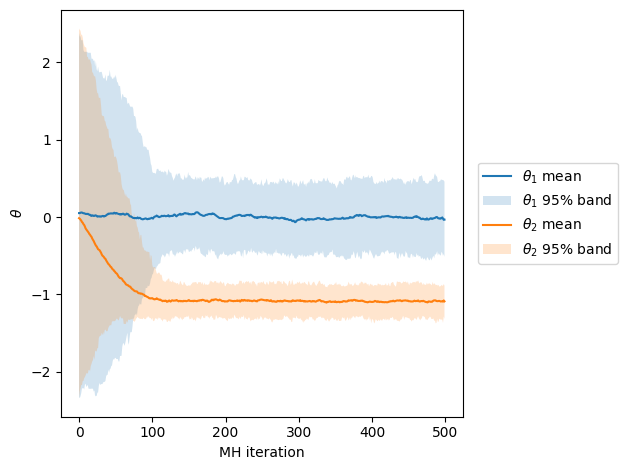

In [236]:
''' Visualize behaviour of the M-H algorithm by drawing
many samples and thereafter computing mean trajectories and
empirical 95% confidence bands.
'''

n_runs = 200 # Number of sample trajectories to draw from the M-H algorithm
n_iters = 500 # Number of iterations to run each M-H algorithm for

theta_trajs = np.zeros((n_runs, n_iters, 2)) # Store trajectories

for r in range(n_runs):
    initial_theta = sample_prior()

    theta_trajs[r] = metropolis_hastings(
        initial_theta=initial_theta,
        temp=temp,
        n_iters=n_iters,
        us=us,
        ys=ys,
        proposal_sd=0.1
    )


x = np.arange(n_iters)
fig, ax = plt.subplots()
for j, label in enumerate([r'$\theta_1$', r'$\theta_2$']):
    mean = theta_trajs[:, :, j].mean(axis=0)
    lo, hi = np.quantile(theta_trajs[:, :, j], [0.025, 0.975], axis=0)

    ax.plot(x, mean, label=f'{label} mean')
    ax.fill_between(x, lo, hi, alpha=0.2, label=f'{label} 95% band')


ax.set_xlabel("MH iteration")
ax.set_ylabel(r"$\theta$")
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
plt.show()

In [209]:
"""Define functions for SMC sampling from the
posterior of the state-space model.
"""


def ess(cur_log_omega, nxt_log_omega):
    """Compute the effective sample size for the set
    of weights the log of which is given by nxt_log_omega - cur_log_omega.
    
    Parameters
    -
    cur_log_omega : ndarray of size (N,)
                    List of logs of evaluations of the 'proposal distribution'
                    (up to proportionality) in a set of sample points.
    nxt_log_omega : ndarray of size (N,)
                    List of logs of evaluations of the 'true distribution'
                    (up to proportionality) in a set of sample points.
    
    Comments
    -
    Works in log-scale to avoid numerical difficulties.
    """
    
    cur = np.asarray(cur_log_omega)
    nxt = np.asarray(nxt_log_omega)
    log_w = nxt - cur
    log_w_normalized = log_w - logsumexp(log_w) # Use logsumexp trick to avoid under/overflow
    return np.exp(-logsumexp(2 * log_w_normalized)) # Number between 0 and some relatively small N; no under/overflow risk


def bisect(f, c, lo, hi, max_iter=50, tol=1e-2, verbose=False):
    """ Approximately compute the point of
    intersection between some function y = f(x) 
    and the line y = c using the bisection method.
    
    Parameters
    -
    f : lambda
        Function to evaluate the intersection of.
    c : float
        y-coordinate of the intersection line.
    lo : float
        x-coordinate of the lower extent of the 
        initial bisection interval.
    hi : float
        x-coordinate of the upper extent of the
        initial bisection interval.
    max_iter : int
        Number of iterations to try bisection for.
    tol : float
        How close to c a result can be to count
        as an intersection. 
    verbose : Boolean, default=False
        Whether or not to display additional
        diagnostic information.
    """
    
    lo, hi = lo, hi
    flo, fhi = f(lo) - c, f(hi) - c
    
    # If many particles are active even at the lower bound
    # temperature, jump directly to the lower bound temperature.
    if flo > 0:
        return lo
    # Impossible for bisection to find an answer in this case.
    # This should not happen (algorithm would probably keep running forever
    # if we would not quit).
    if flo * fhi > 0:
        raise ValueError(f"Bisection requires opposite signs, got f(lo)-c={flo}, f(hi)-c={fhi}"
    )
    
    # Bisection method
    for i in range(max_iter):
        mid = (lo + hi) / 2
        fmid = f(mid) - c
                
        if np.abs(fmid) < tol:
            if verbose:
                print(f'Bisection converged! Midpoint is: {mid}, ESS at midpoint is: {fmid + c}.')
            return mid
        
        flo = f(lo) - c
        
        if flo * fmid < 0:
            hi = mid
        else:
            lo = mid

    if verbose:
        print(f'WARNING: Bisection did not converge.')
    return (lo + hi) / 2


def smc_sampler(ys, us, mh_iters, mh_sd, n_particles, initial_temp, min_temp, max_smc_iters=30, verbose=False):
    """Tempered SMC sampler for approximate sampling from the
    parameter posterior of the linear-Gaussian state space model
    described in Svensson et al. (2017).
    
    Parameters
    -
    ys : ndarray of size (T,)
        List of observations to condition on in the posterior.
    us : ndarray of size (T,)
        List of exogenous input variables in the state-space model.
    mh_iters : int
        Number of iterations to run the mutation Metropolis-Hastings
         kernel for.
    mh_sd : float
        Standard deviation of the proposal distribution in the mutation
        Metropolis-Hastings kernel.
    n_particles : int
        Number of particles to simulate / number of samples to draw.
    initial_temp: float
        Initial tempering parameter.
    min_temp : float
        Minimum tempering parameter; when reaching at most this temperature,
        terminate.
    max_smc_iters : int
        How many tempering iterations of the SMC sampler are allowed before
        we forcibly terminate.
    verbose : Boolean, default=False
        Whether or not to display additional diagnostic information
    """
    
    # Sample an initial point from the prior, to be used as
    # a starting point in Metropolis-Hastings sampling.
    # Prior is uniform on [0, 2.5] x [-2.5, 0].
    initial_particle = sample_prior()
    
    # Use random walk Metropolis-Hastings to sample initial parameter
    # estimates.
    particles = metropolis_hastings(initial_theta=initial_particle,
                                temp=initial_temp,
                                n_iters=3000,
                                proposal_sd=0.2,
                                us=us,
                                ys=ys
                                )[-n_particles:]

    # Run the SMC sampler until minimum tempering is reached
    diagnostics = {} # Keep record of particle and temperature evolution over time
    target_ess = 0.5 * n_particles # Try to keep ESS constantly here using bisection method
    temp = initial_temp
    p = 0
    while temp > min_temp: # Iterate while the tempering strength is sufficiently large
        p += 1
        
        diagnostics[p] = {'particles': particles.copy(), 'temp': temp}
        
        if p > max_smc_iters:
            print(f'WARNING: algorithm did not converge. Returning early...')
            return particles
            
        # Evaluate the 'proposal density up to proportionality' in samples
        log_omega = [log_likelihood(ys=ys,theta=particles[j,:],us=us,temp=temp) \
                + log_prior(particles[j,:]) \
                for j in range(n_particles)] # We keep in log scale to avoid underflow
        
        # Evaluate 'target density up to proportionality' in samples,
        # but we don't know what the target density will be; we choose
        # it adaptively based on the following heuristic:
        # pick the target (depending on a tempering parameter) such that 
        # ESS(proposal/target) = 0.5*n_particles.
        # The dependency between the target densities (up to proportionality) and the
        # tempering strength is encoded in the lambda below
        f = lambda l: ess(log_omega, [log_likelihood(ys=ys,us=us,theta=particles[j,:],temp=l) \
                                + log_prior(particles[j,:]) for j in range(n_particles)])
        
        if verbose:
            print(f'Iteration {p}. Diagnostics: current temperature = {temp},\n \
                particles active at current temperature: {f(temp)},\n \
                particles active if we would jump to lowest temperature: {f(min_temp)}')

        # Use a bisection method to find a good tempering strength
        temp = bisect(f, target_ess, lo=min_temp, hi=temp, verbose=0) 
            
        # Compute normalized log weights using new tempering    
        log_w = np.asarray([log_likelihood(ys=ys,us=us,theta=particles[j,:],temp=temp) \
                + log_prior(particles[j,:]) - log_omega[j] for j in range(n_particles)])
        w_normalized = np.exp(log_w - logsumexp(log_w))
        
        # Sample new indices
        resample_idxs = np.random.choice(np.arange(n_particles), size=n_particles, replace=True, p=w_normalized)

        for j in range(n_particles):
            # Resampling + Metropolis-Hastings mutation
            particles[j, :] = metropolis_hastings(initial_theta=particles[resample_idxs[j]],
                                            temp=temp,
                                            ys=ys,
                                            us=us,
                                            n_iters=mh_iters,
                                            proposal_sd=mh_sd,
                                            verbose=False
                                            )[-1]
            
    diagnostics[p] = {'particles': particles.copy(), 'temp': temp}
    return particles, diagnostics

In [226]:
"""Take an SMC sample from the state-space model.
"""

temp = 10 # Initial tempering strength
min_temp = 0.01
n_particles = 50 # Number of particles
n_observed = 200 # Number of observations from state-space model

# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=n_observed)

# Sample observations for the true, underlying state-space model,
# which has parameters theta1 = 0.8, theta2 = -1.
ys = sample_state_space_model(us=us,T=n_observed) 

thetas, diagnostics = smc_sampler(ys=ys,us=us,mh_iters=500,mh_sd=0.03,n_particles=n_particles,initial_temp=temp,min_temp=min_temp,verbose=True)

Iteration 1. Diagnostics: current temperature = 10,
                 particles active at current temperature: 49.99999999999999,
                 particles active if we would jump to lowest temperature: 6.712152567663933
Iteration 2. Diagnostics: current temperature = 0.5807177734374999,
                 particles active at current temperature: 49.99999999999999,
                 particles active if we would jump to lowest temperature: 1.1152032153171925
Iteration 3. Diagnostics: current temperature = 0.3515110504627227,
                 particles active at current temperature: 49.99999999999999,
                 particles active if we would jump to lowest temperature: 2.7593132046295707
Iteration 4. Diagnostics: current temperature = 0.22819687965355112,
                 particles active at current temperature: 49.99999999999999,
                 particles active if we would jump to lowest temperature: 10.298548061460624
Iteration 5. Diagnostics: current temperature = 0.10876391964787

/tmp/ipykernel_21690/497396738.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


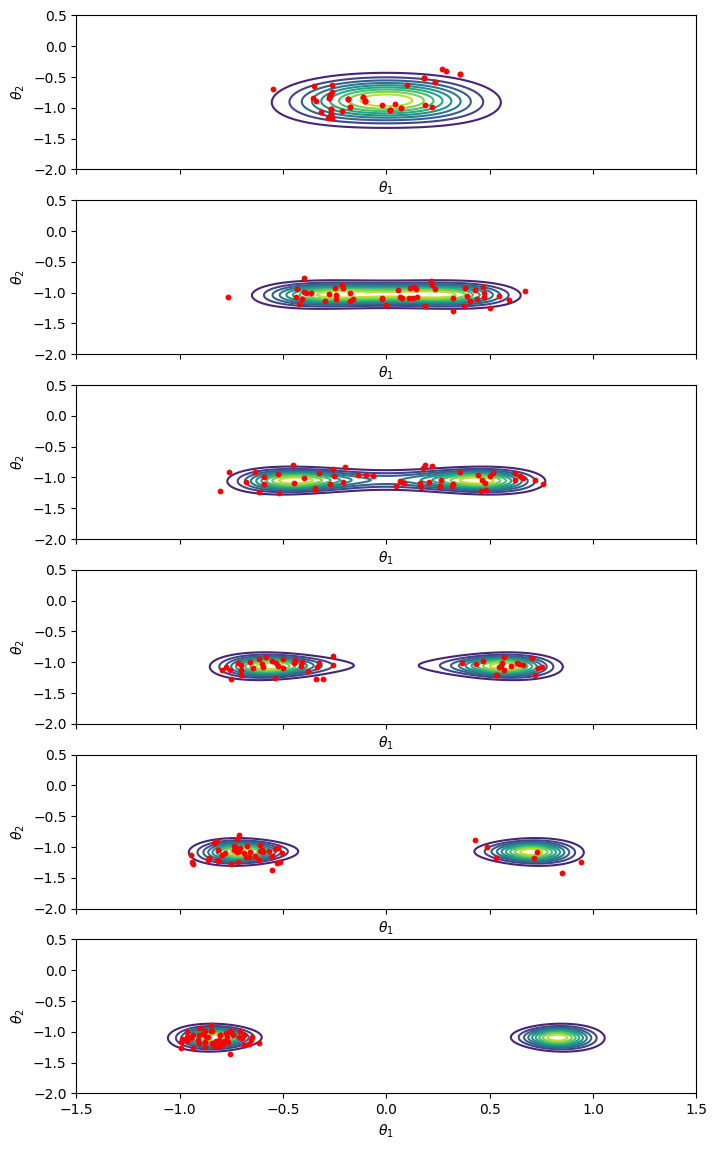

In [227]:
""" Plot the evolution of the tempering sequence
    and the particles across iterations of the
    SMC sampler.
"""

theta1_grid = np.linspace(-1.5, 1.5, 200)
theta2_grid = np.linspace(-2, .5, 200)
Z = np.empty((len(theta1_grid), len(theta2_grid)))

fig, axes = plt.subplots(len(diagnostics), 1, figsize=(8,14), sharex=True)
for ax, (p, val) in zip(axes, diagnostics.items()):

    temp = val['temp']
    particles = val['particles']
    
    for i, t1 in enumerate(theta1_grid):
        for k, t2 in enumerate(theta2_grid):
            theta = np.array([t1, t2])
            Z[i, k] = log_likelihood(ys=ys,us=us,theta=theta,temp=temp) + log_prior(theta)

    Z -= Z.max()
    P = np.exp(Z)
    T1, T2 = np.meshgrid(theta1_grid, theta2_grid, indexing='ij')
    ax.contour(T1, T2, P, levels=10)

    ax.scatter(particles[:, 0], particles[:, 1],
                s=10, alpha=1, color='red', label='particles', zorder=3)

    ax.set_xlabel(r'$\theta_1$')
    ax.set_ylabel(r'$\theta_2$')
    
fig.show()

